In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# !unzip "/content/drive/MyDrive/archive.zip" -d "./medicinal_leaf/"

In [1]:
import numpy as np
import pandas as pd

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import numpy as np
import os
import cv2

In [3]:
dataset_path = '../01_data_augmentation/result'


In [19]:
os.listdir(dataset_path)

['Aloevera',
 'Amla',
 'Bhrami',
 'Bringaraja',
 'Coriender',
 'Curry',
 'Ekka',
 'Hibiscus',
 'Lemon',
 'Mint',
 'Neem',
 'Papaya',
 'Tulsi']

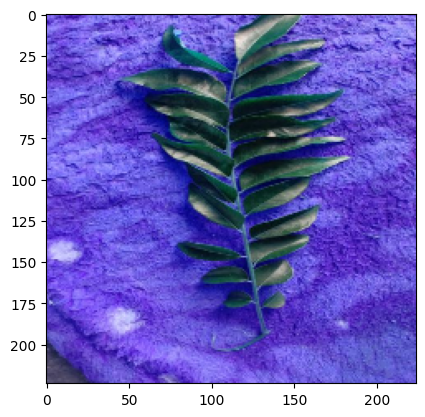

In [ ]:
image_path='../01_data_augmentation/Medicinal_Leaves/Curry/396.jpg'
# Read the image
image = cv2.imread(image_path)
image = cv2.resize(image, (224, 224))
image = image.astype(np.float32) / 255.0
plt.imshow(image)


In [51]:
len(imgs)

12

In [52]:
images

[array([[[0.37254903, 0.57254905, 0.3764706 ],
         [0.36862746, 0.5686275 , 0.37254903],
         [0.36078432, 0.56078434, 0.3647059 ],
         ...,
         [0.15294118, 0.3882353 , 0.2       ],
         [0.14901961, 0.38431373, 0.19607843],
         [0.14901961, 0.38431373, 0.19607843]],
 
        [[0.39607844, 0.59607846, 0.4       ],
         [0.3882353 , 0.5882353 , 0.39215687],
         [0.3764706 , 0.5764706 , 0.38039216],
         ...,
         [0.14901961, 0.38431373, 0.19607843],
         [0.14509805, 0.38039216, 0.19215687],
         [0.14509805, 0.38039216, 0.19215687]],
 
        [[0.35686275, 0.5568628 , 0.36078432],
         [0.36862746, 0.5686275 , 0.37254903],
         [0.38039216, 0.5803922 , 0.38431373],
         ...,
         [0.14117648, 0.3764706 , 0.1882353 ],
         [0.14117648, 0.3764706 , 0.1882353 ],
         [0.14117648, 0.3764706 , 0.1882353 ]],
 
        ...,
 
        [[0.3137255 , 0.60784316, 0.37254903],
         [0.31764707, 0.6117647 , 0.37647

In [55]:
images[0].shape

(224, 224, 3)

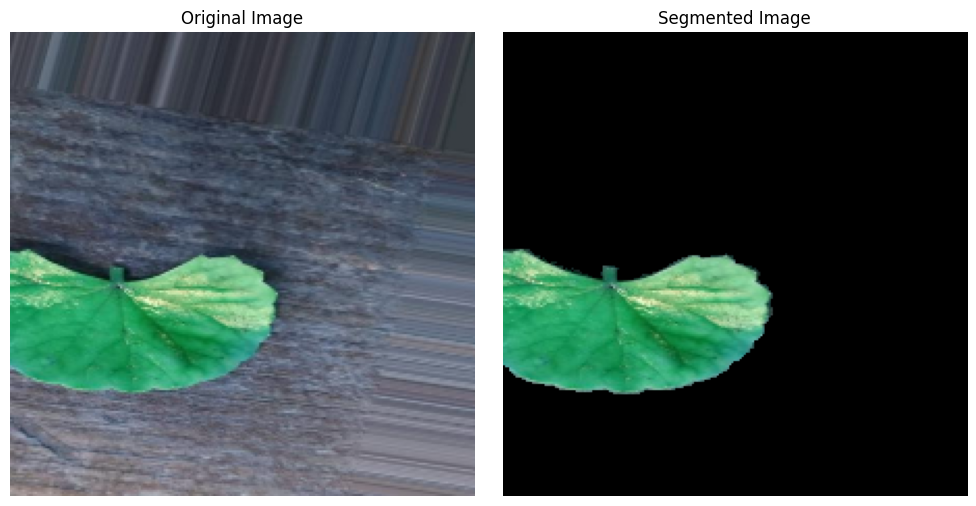

In [58]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# # Load your original and segmented images (replace with your own image paths)
# original_image_path = 'original_image.jpg'
# segmented_image_path = 'segmented_image.jpg'

# # Read images using matplotlib.image.imread
# original_image = mpimg.imread(original_image_path)
# segmented_image = mpimg.imread(segmented_image_path)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot original image on the first subplot
axes[0].imshow(images[1400])
axes[0].set_title('Original Image')
axes[0].axis('off')

# Plot segmented image on the second subplot
axes[1].imshow(seg_images[1400])
axes[1].set_title('Segmented Image')
axes[1].axis('off')

# Adjust layout and display the figure
plt.tight_layout()
plt.show()


In [65]:
pd.DataFrame(np.array(y_train)).value_counts()

3     406
4     400
8     385
12    382
6     379
0     378
1     373
10    372
5     367
2     364
9     364
11    362
7     361
Name: count, dtype: int64

In [66]:
pd.DataFrame(np.array(y_test)).value_counts()

7     140
9     139
11    138
2     136
5     134
10    131
1     129
0     125
6     125
12    119
8     117
4     100
3      98
Name: count, dtype: int64

In [68]:
import numpy as np

In [71]:
# np.array(X_train).shape,np.array(y_train).shape

In [35]:
X_test

[array([[[0.5176471 , 0.5647059 , 0.57254905],
         [0.52156866, 0.5686275 , 0.5764706 ],
         [0.53333336, 0.5803922 , 0.5882353 ],
         ...,
         [0.37254903, 0.41960785, 0.42745098],
         [0.38039216, 0.42745098, 0.43529412],
         [0.35686275, 0.39607844, 0.42352942]],
 
        [[0.53333336, 0.5803922 , 0.5882353 ],
         [0.5294118 , 0.5764706 , 0.58431375],
         [0.54509807, 0.5921569 , 0.6       ],
         ...,
         [0.3529412 , 0.4       , 0.40784314],
         [0.3764706 , 0.41960785, 0.43137255],
         [0.3647059 , 0.40784314, 0.42745098]],
 
        [[0.54901963, 0.59607846, 0.6039216 ],
         [0.5372549 , 0.58431375, 0.5921569 ],
         [0.56078434, 0.60784316, 0.6156863 ],
         ...,
         [0.40784314, 0.45490196, 0.4627451 ],
         [0.36862746, 0.41568628, 0.42352942],
         [0.3764706 , 0.41960785, 0.43529412]],
 
        ...,
 
        [[0.54509807, 0.5921569 , 0.6       ],
         [0.49019608, 0.5372549 , 0.54509

In [13]:
# Constants
IMAGE_RES = 224
BATCH_SIZE = 32
# Load the dataset
data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(IMAGE_RES, IMAGE_RES),
    batch_size=BATCH_SIZE,
    validation_split=0.2,  # 20% of the data will be used for testing
    subset="training",     # Specify "training" to get the training subset
    seed=42,
    label_mode='int'
)

Found 6525 files belonging to 13 classes.
Using 5220 files for training.


In [7]:
data

<BatchDataset shapes: ((None, 224, 224, 3), (None,)), types: (tf.float32, tf.int32)>

In [13]:

for images, labels in data:
    # `images` would be a [10batch of images with shape (batch_size, 224, 224, 3)
    # `labels` would be a batch of labels with shape (batch_size,)
    print(labels)
    print(images)
    break

tf.Tensor(
[10  6  0  4  5  4  1 11 11  6  5 12  8  5  6  8  4  3 10  9  5  8  6  4
 12 11  3 11  2 12 11  6], shape=(32,), dtype=int32)
tf.Tensor(
[[[[223.       223.       215.      ]
   [223.       223.       215.      ]
   [223.       223.       215.      ]
   ...
   [228.       229.       221.      ]
   [228.       229.       221.      ]
   [228.       229.       221.      ]]

  [[223.       223.       215.      ]
   [223.       223.       215.      ]
   [223.       223.       215.      ]
   ...
   [228.       229.       221.      ]
   [228.       229.       221.      ]
   [228.       229.       221.      ]]

  [[223.       223.       215.      ]
   [223.       223.       215.      ]
   [223.       223.       215.      ]
   ...
   [228.       229.       221.      ]
   [228.       229.       221.      ]
   [228.       229.       221.      ]]

  ...

  [[236.       235.       231.      ]
   [236.       235.       231.      ]
   [236.       235.       231.      ]
   ...
   [238.     

In [14]:
num_examples = data.cardinality().numpy()
num_classes = len(data.class_names)
num_examples

164

In [15]:
data.class_names

['Aloevera',
 'Amla',
 'Bhrami',
 'Bringaraja',
 'Coriender',
 'Curry',
 'Ekka',
 'Hibiscus',
 'Lemon',
 'Mint',
 'Neem',
 'Papaya',
 'Tulsi']

In [16]:
num_classes

13

In [9]:
# Split the data into training and testing
testing_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(IMAGE_RES, IMAGE_RES),
    batch_size=BATCH_SIZE,
    validation_split=0.2,  # No validation split for testing
    seed=42,
    label_mode='int',
    subset="validation"    # Specify "validation" to get the testing subset
)

Found 6525 files belonging to 13 classes.
Using 1305 files for validation.


In [37]:
for images, labels in data.take(1):  # Take one batch from the dataset
    print(labels)
    print(images)

tf.Tensor(
[11  9 10  7 11 12  8  9  6  3  0  5 11  4  3  2  9  7 10 12  1 10 11  2
  9  0  4 11  7  0  3  9], shape=(32,), dtype=int32)
tf.Tensor(
[[[[ 51.        71.        20.      ]
   [ 58.0625    79.07143   29.080357]
   [ 63.08482   85.25893   37.129463]
   ...
   [ 40.955383  52.955383  16.955383]
   [ 48.442078  60.442078  24.442078]
   [ 55.        67.        31.      ]]

  [[ 89.84375  111.35714   59.852676]
   [ 81.12823  102.8871    52.64605 ]
   [ 69.50998   91.94758   43.73029 ]
   ...
   [ 36.437714  47.933247  12.942177]
   [ 41.89753   53.393063  18.401993]
   [ 46.928574  58.424107  23.433037]]

  [[132.35268  155.5268   103.52679 ]
   [107.347916 130.36888   79.70662 ]
   [ 78.485886 101.961914  53.279816]
   ...
   [ 30.584599  42.10692    8.281027]
   [ 33.556736  45.079056  11.253163]
   [ 36.736607  48.258926  14.433035]]

  ...

  [[ 87.52231   80.52231   70.870514]
   [ 83.662254  76.662254  67.01046 ]
   [ 76.358055  69.85007   60.402695]
   ...
   [ 30.40712

In [72]:
# Constants
IMAGE_RES = 224  # InceptionV3 input shape
BATCH_SIZE = 32

## ***Normalizing***:
---







In [73]:
def format_image(image, label):
    image = tf.image.resize(image, (IMAGE_RES, IMAGE_RES)) / 255.0
    return image, label
train_data = data
# Define the validation split ratio
validation_split = 0.2
num_validation_samples = int(num_examples * validation_split)
validation_data = data.take(num_validation_samples)

train_batches = train_data.map(format_image).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_batches = validation_data.map(format_image).cache().prefetch(buffer_size=tf.data.AUTOTUNE)


In [74]:
num_examples*validation_split

32.800000000000004

In [13]:
len(train_batches)

164

In [14]:
len(validation_batches)

32

In [23]:
for i,j in validation_batches:
  print(i,j)
  break

tf.Tensor(
[[[[0.8        0.7921569  0.79607844]
   [0.8        0.7921569  0.79607844]
   [0.8        0.7921569  0.79607844]
   ...
   [0.6369692  0.6291261  0.63304764]
   [0.8079538  0.80011064 0.8040322 ]
   [0.88046217 0.87261903 0.8765406 ]]

  [[0.8        0.7921569  0.79607844]
   [0.8        0.7921569  0.79607844]
   [0.8        0.7921569  0.79607844]
   ...
   [0.6562022  0.64835906 0.6522806 ]
   [0.87919194 0.8713488  0.87527037]
   [0.8801821  0.87233895 0.8762605 ]]

  [[0.8        0.7921569  0.79607844]
   [0.8        0.7921569  0.79607844]
   [0.8        0.7921569  0.79607844]
   ...
   [0.82125366 0.8134105  0.8173321 ]
   [0.86698    0.8591369  0.86305845]
   [0.88074225 0.8728991  0.8768207 ]]

  ...

  [[0.86236346 0.8545203  0.8584419 ]
   [0.8627451  0.85490197 0.85882354]
   [0.8666667  0.85882354 0.8627451 ]
   ...
   [0.5137255  0.5058824  0.5176471 ]
   [0.5137255  0.5058824  0.5176471 ]
   [0.5137255  0.5058824  0.5176471 ]]

  [[0.864636   0.85679287 0.860714

In [15]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

In [16]:
# Create the base model (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_RES, IMAGE_RES, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False

# Add custom layers for classification
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')

# Create the final model
model = tf.keras.Sequential([
    base_model,
    global_average_layer,
    prediction_layer
])

In [17]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 13)                16653     
                                                                 
Total params: 2,274,637
Trainable params: 16,653
Non-trainable params: 2,257,984
_________________________________________________________________


In [19]:
history = model.fit(train_batches, validation_data=validation_batches, epochs=10)

Epoch 1/10
164/164 [==============================] - 1574s 9s/step - loss: 1.0211 - accuracy: 0.7071 - val_loss: 0.4409 - val_accuracy: 0.8994
Epoch 2/10
164/164 [==============================] - 1062s 6s/step - loss: 0.3379 - accuracy: 0.9257 - val_loss: 0.2423 - val_accuracy: 0.9531
Epoch 3/10
164/164 [==============================] - 1309s 8s/step - loss: 0.2078 - accuracy: 0.9619 - val_loss: 0.1625 - val_accuracy: 0.9697
Epoch 4/10
164/164 [==============================] - 1335s 8s/step - loss: 0.1466 - accuracy: 0.9768 - val_loss: 0.1207 - val_accuracy: 0.9775
Epoch 5/10
164/164 [==============================] - 1295s 8s/step - loss: 0.1107 - accuracy: 0.9851 - val_loss: 0.0944 - val_accuracy: 0.9873
Epoch 6/10
164/164 [==============================] - 1094s 7s/step - loss: 0.0868 - accuracy: 0.9891 - val_loss: 0.0757 - val_accuracy: 0.9932
Epoch 7/10
164/164 [==============================] - 1032s 6s/step - loss: 0.0699 - accuracy: 0.9937 - val_loss: 0.0616 - val_accuracy:

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 80)                  │         102,480 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,565,426 (9.79 MB)

 Trainable params: 102,480 (400.31 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 204,962 (800.64 KB)

In [20]:
model.save('model_inceptionv2_withaug500.h5')

C:\Users\GTSHADOOP\anaconda3\lib\site-packages\keras\engine\functional.py:1410: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  layer_config = serialize_layer_fn(layer)


In [ ]:
print(history)

In [ ]:
# acc = history.history['accuracy']
# val_acc = history.history['val_accuracy']

# loss = history.history['loss']
# val_loss = history.history['val_loss']

# epochs_range = range(Epoch)
# epochs_range = range(Epoch)

# plt.figure(figsize=(8, 8))
# plt.subplot(1, 2, 1)
# plt.plot(epochs_range, acc, label='Training Accuracy')
# plt.plot(epochs_range, val_acc, label='Validation Accuracy')
# plt.legend(loc='lower right')
# plt.title('Training and Validation Accuracy')

# plt.subplot(1, 2, 2)
# plt.plot(epochs_range, loss, label='Training Loss')
# plt.plot(epochs_range, val_loss, label='Validation Loss')
# plt.legend(loc='upper right')
# plt.title('Training and Validation Loss for MobileNet Model')
# plt.show()

In [75]:
model=loaded_model

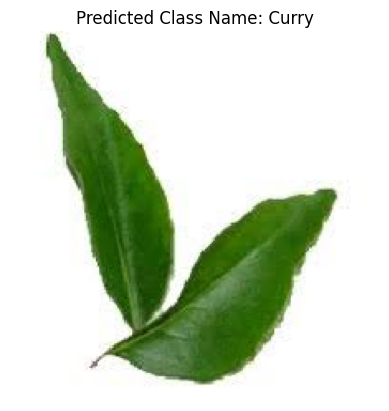

In [76]:
import os
test_dir = '../01_data_augmentation/result/Tulsi/'
input_image_path = os.path.join(test_dir, os.listdir(test_dir)[0])
input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
input_image_array = img_to_array(input_image)
input_image_array = input_image_array / 255.0  # Normalize the image
input_image_array = input_image_array[tf.newaxis, ...]
predictions = model.predict(input_image_array)
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
predicted_class_name = data.class_names[predicted_class_index]
plt.imshow(input_image)
plt.title("Predicted Class Name: " + predicted_class_name)
plt.axis("off")
plt.show()

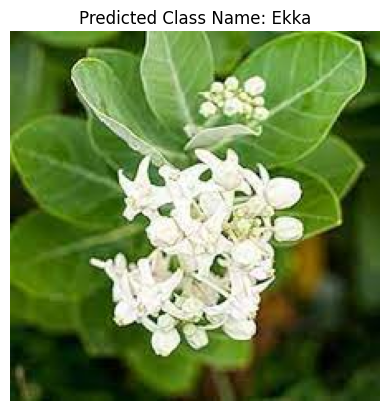

In [77]:
import os
test_dir = '../01_data_augmentation/result/Tulsi/'
input_image_path = os.path.join(test_dir, os.listdir(test_dir)[0])
input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
input_image_array = img_to_array(input_image)
input_image_array = input_image_array / 255.0  # Normalize the image
input_image_array = input_image_array[tf.newaxis, ...]
predictions = model.predict(input_image_array)
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
predicted_class_name = data.class_names[predicted_class_index]
plt.imshow(input_image)
plt.title("Predicted Class Name: " + predicted_class_name)
plt.axis("off")
plt.show()

In [78]:
model

In [79]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 13)                16653     
                                                                 
Total params: 2,274,637
Trainable params: 16,653
Non-trainable params: 2,257,984
_________________________________________________________________


In [3]:
from tensorflow.keras.models import load_model
# model.save('model_inceptionv2_withaug500.h5')
loaded_model = load_model('model_inceptionv2_withaug500.h5')

In [4]:
loaded_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 13)                16653     
                                                                 
Total params: 2,274,637
Trainable params: 16,653
Non-trainable params: 2,257,984
_________________________________________________________________


In [41]:
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [80]:
validation=loaded_model.evaluate(validation_batches)

32/32 [==============================] - 209s 6s/step - loss: 0.0367 - accuracy: 1.0000


In [81]:
print("\n")
print("validation accuracy :",validation[1])
print("\n")
print("validation loss :",validation[0])
print("\n")



validation accuracy : 1.0


validation loss : 0.03672150894999504




In [7]:
IMAGE_RES=224

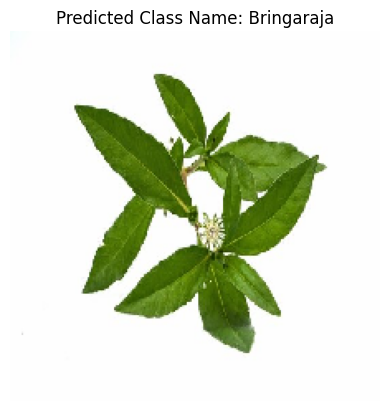

In [18]:
import os
test_dir = '../01_data_augmentation/result/Tulsi/'
input_image_path = os.path.join(test_dir, os.listdir(test_dir)[0])
input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
input_image_array = img_to_array(input_image)
input_image_array = input_image_array / 255.0  # Normalize the image
input_image_array = input_image_array[tf.newaxis, ...]
predictions = loaded_model.predict(input_image_array)
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
predicted_class_name = data.class_names[predicted_class_index]
plt.imshow(input_image)
plt.title("Predicted Class Name: " + predicted_class_name)
plt.axis("off")
plt.show()

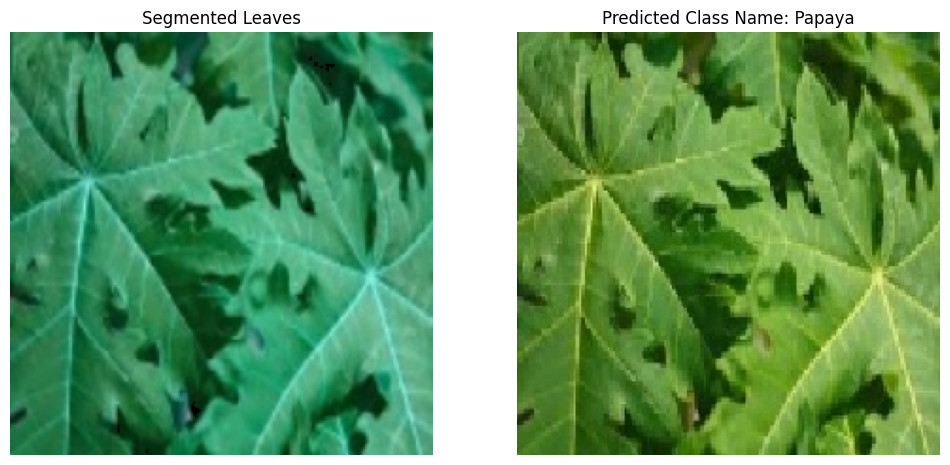

In [ ]:
input_image_path ="../01_data_augmentation/Medicinal_Leaves/Papaya/52.jpg"

input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
input_image_array = img_to_array(input_image)
input_image_array = input_image_array / 255.0  # Normalize the image
input_image_array = input_image_array[tf.newaxis, ...]
predictions = loaded_model.predict(input_image_array)
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
predicted_class_name = names[predicted_class_index]

image = cv2.imread(input_image_path)
image = cv2.resize(image, (224, 224))
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# Define color range for leaf segmentation in HSV space
# These values might need to be adjusted based on the leaf color and lighting conditions
lower_bound = np.array([30, 40, 40])  # Lower bound for green color
upper_bound = np.array([90, 255, 255])  # Upper bound for green color
# Create a binary mask where white represents the areas within the color range
mask = cv2.inRange(hsv_image, lower_bound, upper_bound)
# Perform bitwise AND operation to extract the leaves from the original image
segmented_leaves = cv2.bitwise_and(image, image, mask=mask)
segmented_leaves = segmented_leaves.astype(np.float32) / 255.0

segmented_leaves1 = segmented_leaves[tf.newaxis, ...]

# predictions = loaded_model.predict(segmented_leaves1)
# predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
# predicted_class_name = names[predicted_class_index]


# Create a figure and set of subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Display segmented leaves
axs[0].imshow(segmented_leaves)
axs[0].set_title("Segmented Leaves")
axs[0].axis("off")

# Display input image
axs[1].imshow(input_image)
axs[1].set_title("Predicted Class Name: " + predicted_class_name)
axs[1].axis("off")

# Show the plot
plt.show()


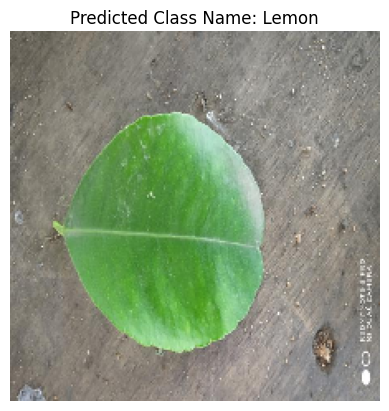

In [ ]:

input_image_path ='../01_data_augmentation/Medicinal_Leaves/Lemon/176.jpg'
input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
input_image_array = img_to_array(input_image)
input_image_array = input_image_array / 255.0  # Normalize the image
input_image_array = input_image_array[tf.newaxis, ...]
predictions = loaded_model.predict(input_image_array)
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
predicted_class_name = data.class_names[predicted_class_index]
plt.imshow(input_image)
plt.title("Predicted Class Name: " + predicted_class_name)
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
# loaded_model = load_model('/content/drive/MyDrive/cnn_model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# !pip show opencv-python

Name: opencv-python
Version: 4.10.0.84
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: numpy
Required-by: dopamine_rl, imgaug


In [85]:


def load_and_preprocess_image(image_path, image_size):
    # Load the image
    image = tf.keras.preprocessing.image.load_img(image_path, target_size=(image_size, image_size))
    
    # Convert the image to a numpy array
    image_array = tf.keras.preprocessing.image.img_to_array(image)
    
    # Expand dimensions to match the input shape of the model
    image_array = tf.expand_dims(image_array, axis=0)
    
    # Normalize the image array
    image_array = image_array / 255.0  # Assuming the model was trained on normalized images
    
    return image_array


In [ ]:
img_features=load_and_preprocess_image("../01_data_augmentation/Medicinal_Leaves/Mint/596.jpg",224)
img_features.shape

TensorShape([1, 224, 224, 3])

In [87]:
pred=loaded_model.predict(img_features)
pred=np.argmax(pred)
pred

9

In [88]:
names[pred]

'Mint'